# Statistics

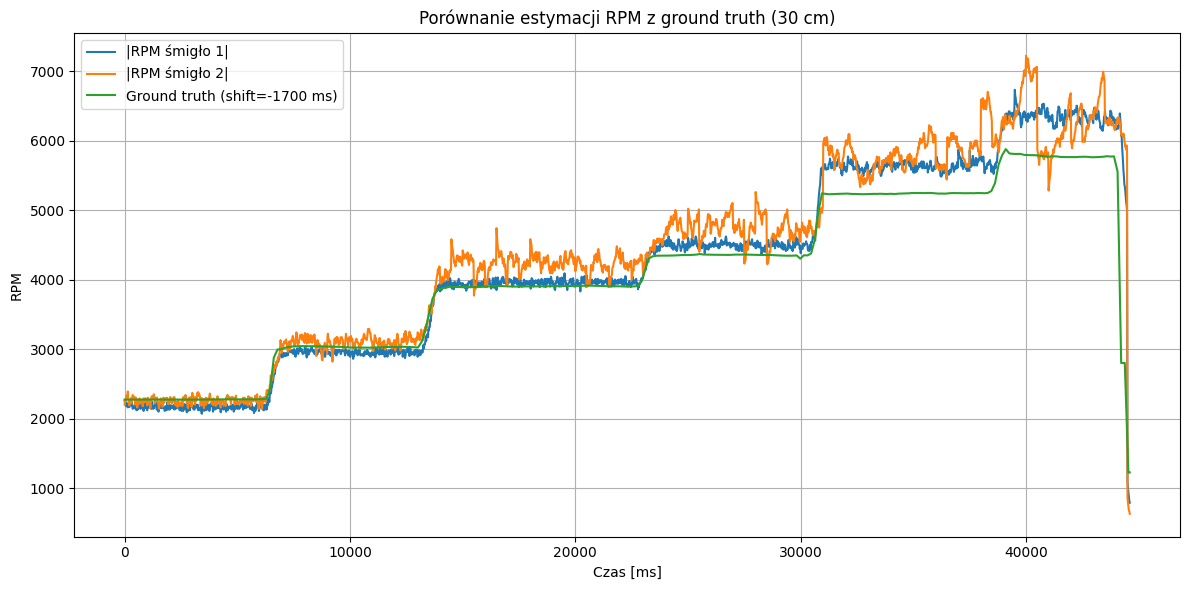

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rpm_file = "outputs/rpm_results.csv"
gt_file = "gt/30_cm.xls"
gt_shift_ms = -1700
plot_max_time_ms = 156500

plot_df = pd.read_csv(rpm_file)
plot_df.columns = [str(c).strip() for c in plot_df.columns]


time_col = "time"
rpm1_col = "c1"
rpm2_col = "c2"

plot_df[time_col] = pd.to_numeric(plot_df[time_col], errors="coerce")
plot_df[rpm1_col] = pd.to_numeric(plot_df[rpm1_col], errors="coerce")
plot_df[rpm2_col] = pd.to_numeric(plot_df[rpm2_col], errors="coerce")

plot_df["rpm1_abs"] = plot_df[rpm1_col].abs()
plot_df["rpm2_abs"] = plot_df[rpm2_col].abs()

if plot_max_time_ms is not None:
    plot_df = plot_df[plot_df[time_col] <= plot_max_time_ms].copy()

gt_df = pd.read_csv(gt_file, sep="\t")
gt_df.columns = [str(c).strip() for c in gt_df.columns]

gt_df["Time"] = gt_df["Time"].astype(str).str.replace(",", ".", regex=False).astype(float)
gt_df["Value"] = gt_df["Value"].astype(str).str.replace(",", ".", regex=False).astype(float)
gt_df["Time_shifted"] = gt_df["Time"] + gt_shift_ms

x_alg = plot_df[time_col].to_numpy(dtype=float)
x_gt = gt_df["Time_shifted"].to_numpy(dtype=float)
y_gt = gt_df["Value"].to_numpy(dtype=float)

plot_df["gt_interp"] = np.interp(x_alg, x_gt, y_gt, left=np.nan, right=np.nan)

plt.figure(figsize=(12, 6))
plt.plot(plot_df[time_col], plot_df["rpm1_abs"], label="|RPM śmigło 1|")
plt.plot(plot_df[time_col], plot_df["rpm2_abs"], label="|RPM śmigło 2|")
plt.plot(plot_df[time_col], plot_df["gt_interp"], label=f"Ground truth (shift={gt_shift_ms} ms)")
plt.xlabel("Czas [ms]")
plt.ylabel("RPM")
plt.title("Porównanie estymacji RPM z ground truth (30 cm)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def plot_rpm_with_metrics(
    rpm_file = "outputs/rpm_results_30.csv",
    gt_file = "gt/30_cm.xls",
    alg_col_for_metrics="c1",
    gt_shift_ms=0.0,
    plot_max_time_ms=None,
    metric_t0_ms=None,
    metric_t1_ms=None,
    take_abs=True,
    show_centroid_1=True,
    show_centroid_2=True,
    figsize=(14, 7)
):
    plot_df = pd.read_csv(rpm_file)
    plot_df.columns = [str(c).strip() for c in plot_df.columns]

    time_col = "time"
    rpm1_col = "c1"
    rpm2_col = "c2"

    required_cols = [time_col, rpm1_col, rpm2_col, alg_col_for_metrics]
    for col in required_cols:
        if col not in plot_df.columns:
            raise ValueError(f"Brakuje kolumny '{col}' w pliku {rpm_file}")

    plot_df[time_col] = pd.to_numeric(plot_df[time_col], errors="coerce")
    plot_df[rpm1_col] = pd.to_numeric(plot_df[rpm1_col], errors="coerce")
    plot_df[rpm2_col] = pd.to_numeric(plot_df[rpm2_col], errors="coerce")
    plot_df[alg_col_for_metrics] = pd.to_numeric(plot_df[alg_col_for_metrics], errors="coerce")

    plot_df = plot_df.dropna(subset=[time_col]).copy()

    if take_abs:
        plot_df["rpm1_plot"] = plot_df[rpm1_col].abs()
        plot_df["rpm2_plot"] = plot_df[rpm2_col].abs()
        plot_df["alg_metric"] = plot_df[alg_col_for_metrics].abs()
    else:
        plot_df["rpm1_plot"] = plot_df[rpm1_col]
        plot_df["rpm2_plot"] = plot_df[rpm2_col]
        plot_df["alg_metric"] = plot_df[alg_col_for_metrics]

    if plot_max_time_ms is not None:
        plot_df = plot_df[plot_df[time_col] <= plot_max_time_ms].copy()

    plot_df = plot_df.sort_values(time_col).reset_index(drop=True)

    gt_df = pd.read_csv(gt_file, sep="\t")
    gt_df.columns = [str(c).strip() for c in gt_df.columns]


    gt_df["Time"] = gt_df["Time"].astype(str).str.replace(",", ".", regex=False).astype(float)
    gt_df["Value"] = gt_df["Value"].astype(str).str.replace(",", ".", regex=False).astype(float)

    gt_df["time_ms"] = gt_df["Time"] + gt_shift_ms
    gt_df["gt_rpm"] = gt_df["Value"]

    if plot_max_time_ms is not None:
        gt_df = gt_df[gt_df["time_ms"] <= plot_max_time_ms].copy()

    gt_df = gt_df.sort_values("time_ms").reset_index(drop=True)


    x_alg_plot = plot_df[time_col].to_numpy(dtype=float)
    x_gt = gt_df["time_ms"].to_numpy(dtype=float)
    y_gt = gt_df["gt_rpm"].to_numpy(dtype=float)

    gt_interp_for_plot = np.interp(x_alg_plot, x_gt, y_gt, left=np.nan, right=np.nan)
    plot_df["gt_interp_plot"] = gt_interp_for_plot


    if metric_t0_ms is None:
        metric_t0_ms = max(
            np.nanmin(plot_df[time_col].to_numpy(dtype=float)),
            np.nanmin(gt_df["time_ms"].to_numpy(dtype=float))
        )

    if metric_t1_ms is None:
        metric_t1_ms = min(
            np.nanmax(plot_df[time_col].to_numpy(dtype=float)),
            np.nanmax(gt_df["time_ms"].to_numpy(dtype=float))
        )

    eval_df = gt_df[(gt_df["time_ms"] >= metric_t0_ms) & (gt_df["time_ms"] <= metric_t1_ms)].copy()

    x_eval = eval_df["time_ms"].to_numpy(dtype=float)
    y_true = eval_df["gt_rpm"].to_numpy(dtype=float)
    x_alg = plot_df[time_col].to_numpy(dtype=float)
    y_alg = plot_df["alg_metric"].to_numpy(dtype=float)
    y_pred = np.interp(x_eval, x_alg, y_alg, left=np.nan, right=np.nan)

    valid = np.isfinite(x_eval) & np.isfinite(y_pred) & np.isfinite(y_true)

    x_eval = x_eval[valid]
    y_pred = y_pred[valid]
    y_true = y_true[valid]

    err = y_pred - y_true
    abs_err = np.abs(err)

    mae = np.mean(abs_err)
    rmse = np.sqrt(np.mean(err ** 2))
    medae = np.median(abs_err)

    denom = np.sum(np.abs(y_true))
    wape = 100.0 * np.sum(abs_err) / denom if denom > 0 else np.nan

    true_mean = np.mean(np.abs(y_true))
    nrmse_mean = 100.0 * rmse / true_mean if true_mean > 0 else np.nan

    metrics = {
        "alg_col": alg_col_for_metrics,
        "gt_shift_ms": float(gt_shift_ms),
        "metric_t0_ms": float(metric_t0_ms),
        "metric_t1_ms": float(metric_t1_ms),
        "n_points_used": int(len(x_eval)),
        "MAE_RPM": float(mae),
        "RMSE_RPM": float(rmse),
        "MedAE_RPM": float(medae),
        "WAPE_percent": float(wape),
        "NRMSE_mean_percent": float(nrmse_mean),
    }

    compare_df = pd.DataFrame({
        "time_ms": x_eval,
        "pred_rpm": y_pred,
        "gt_rpm": y_true,
        "error": err,
        "abs_error": abs_err,
    })


    plt.figure(figsize=figsize)

    if show_centroid_1:
        plt.plot(
            plot_df[time_col],
            plot_df["rpm1_plot"],
            label="|RPM śmigło 1|",
            linewidth=1.5
        )

    if show_centroid_2:
        plt.plot(
            plot_df[time_col],
            plot_df["rpm2_plot"],
            label="|RPM śmigło 2|",
            linewidth=1.5
        )

    plt.plot(
        plot_df[time_col],
        plot_df["gt_interp_plot"],
        label=f"Ground truth (shift={gt_shift_ms} ms)",
        linewidth=2.0
    )

    plt.axvline(metric_t0_ms, linestyle="--", linewidth=2)
    plt.axvline(metric_t1_ms, linestyle="--", linewidth=2)
    plt.axvspan(metric_t0_ms, metric_t1_ms, alpha=0.12)

    title = (
        f"Porównanie RPM | metryki dla {alg_col_for_metrics} | "
        f" MAE={mae:.2f} RPM | WAPE={wape:.2f}%"
    )

    plt.xlabel("Czas [ms]")
    plt.ylabel("RPM")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(rpm_file)
    return metrics, compare_df

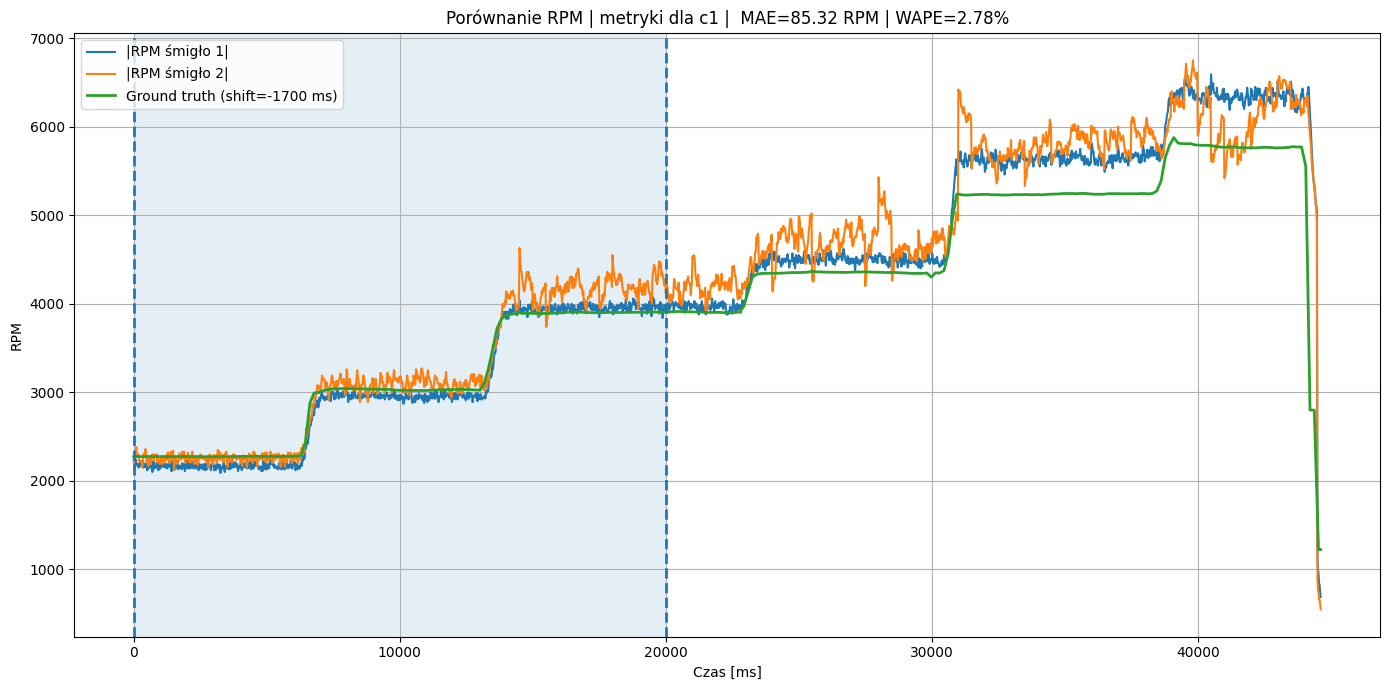

outputs/rpm_results_30.csv


{'alg_col': 'c1',
 'gt_shift_ms': -1700.0,
 'metric_t0_ms': 0.0,
 'metric_t1_ms': 20000.0,
 'n_points_used': 125,
 'MAE_RPM': 85.31599999999997,
 'RMSE_RPM': 97.94294134852188,
 'MedAE_RPM': 76.30000000000018,
 'WAPE_percent': 2.784004627955744,
 'NRMSE_mean_percent': 3.1960429695471317}

In [12]:
metrics, compare_df = plot_rpm_with_metrics(
    rpm_file = "outputs/rpm_results_30.csv",
    gt_file = "gt/30_cm.xls",
    alg_col_for_metrics="c1",
    gt_shift_ms=-1700,
    plot_max_time_ms=73060,
    metric_t0_ms=0,
    metric_t1_ms=20000,
    take_abs=True
)

metrics